# Fig. 2a, 2b, and 2c

In [1]:
from pathlib import Path

import pandas as pd


PANEL_FILE = Path("PanelResults") / "worker_day_panel.csv"
OUTPUT_DIR = Path("MainFigures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PANEL_FILE, encoding="utf-8-sig")
df_merged = pd.DataFrame({
    "Rider": panel["worker_id"],
    "Date": panel["Date"],
    "Orders": panel["OrderCount"],
    "On-dutyHour": panel["On-dutyHour"],
    "Workload": panel["Workload"],
    "WorkIntensity": panel["WorkIntensity"],
    "RestCount": panel["RestCount"],
    "RestDuration": panel["RestHour"],
    "RestRatio": panel["RestRatio"],
    "Location": panel["Location"],
    "Level": panel["WorkerClass"],
})

numeric_columns = [
    "Orders",
    "On-dutyHour",
    "Workload",
    "WorkIntensity",
    "RestCount",
    "RestDuration",
    "RestRatio",
]
for column in numeric_columns:
    df_merged[column] = pd.to_numeric(df_merged[column], errors="coerce")

print(f"Rows loaded: {len(df_merged)}")
print(df_merged["Location"].value_counts(dropna=False).to_string())


Rows loaded: 52568
Location
Shanghai    34726
Harbin      17842


C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_87176\1627290326.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.5)


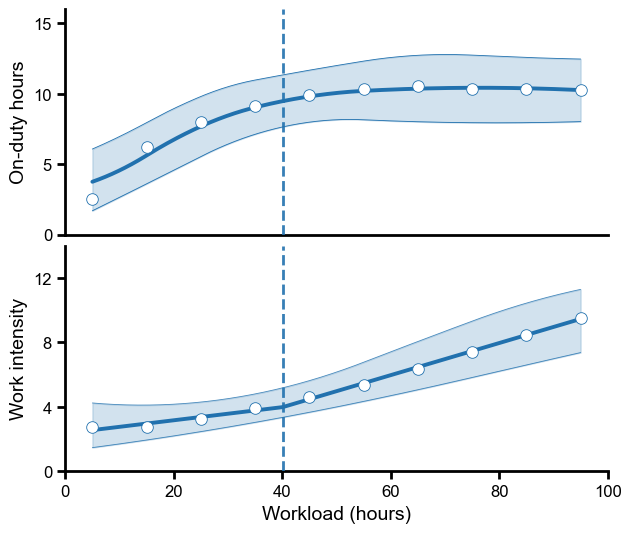

Harbin threshold: 40.09 hours


C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_87176\1627290326.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.5)


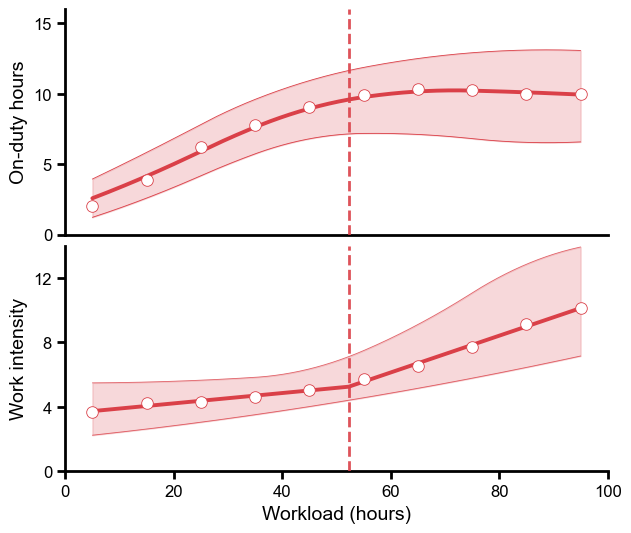

Shanghai threshold: 52.22 hours


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import UnivariateSpline, make_interp_spline
from scipy.ndimage import uniform_filter1d
import pwlf
import os
import warnings

# ===============================
# Global journal‑style settings
# ===============================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0,
    'lines.solid_capstyle': 'round'
})
FONT_SIZE = 14

# ===============================
# Unified color manager
# ===============================
def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)

COLORS = {
    "Shanghai": {
        "fill":    hex_to_rgba("#da4048", 0.2),
        "line":    hex_to_rgba("#da4048", 1.0),
        "band_lo": hex_to_rgba("#da4048", 1.0),
        "band_hi": hex_to_rgba("#da4048", 1.0),
        "edge":    hex_to_rgba("#da4048", 1.0),
        "face":    'white'
    },
    "Harbin": {
        "fill":    hex_to_rgba("#2171AE", 0.2),
        "line":    hex_to_rgba("#2171AE", 1.0),
        "band_lo": hex_to_rgba("#2171AE", 1.0),
        "band_hi": hex_to_rgba("#2171AE", 1.0),
        "edge":    hex_to_rgba("#2171AE", 1.0),
        "face":    'white'
    }
}

save_dir = str(OUTPUT_DIR)
os.makedirs(save_dir, exist_ok=True)

# ===============================
# Binning (consistent intervals)
# ===============================
bins = np.arange(0, 101, 10)
df_merged['Nominal_bin'] = pd.cut(
    df_merged['Workload'],
    bins=bins,
    include_lowest=True,
    right=False
)

# ===============================
# Revised smoothing: mean smoothed, quantile boundaries via direct spline
# ===============================
def compute_smoothed_bands(x, y_mean, y_low, y_high, smooth_factor=0.05):
    """Apply moving-average + spline smoothing with boundary constraints."""
    df = pd.DataFrame({'x': x, 'mean': y_mean, 'low': y_low, 'high': y_high}).dropna()
    if len(df) < 4:
        return x, y_mean, y_low, y_high
    
    w = min(3, len(df) // 2)
    for col in ['mean', 'low', 'high']:
        df[f'{col}_s'] = uniform_filter1d(df[col].values, size=w, mode='nearest')
        
    x_s = np.linspace(df['x'].min(), df['x'].max(), 300)
    s_adj = smooth_factor * (5 / max(len(df), 1))
    
    m = UnivariateSpline(df['x'], df['mean_s'], k=2, s=s_adj)(x_s)
    l = UnivariateSpline(df['x'], df['low_s'], k=2, s=s_adj*1.5)(x_s)
    h = UnivariateSpline(df['x'], df['high_s'], k=2, s=s_adj*1.5)(x_s)
    # Ensure bands do not cross mean
    l = np.minimum(l, m - 0.1)
    h = np.maximum(h, m + 0.1)
    
    return x_s, m, l, h

# ===============================
# Main plotting function
# ===============================
def plot_location(location):
    df_loc = df_merged[df_merged['Location'] == location].copy()
    if len(df_loc) == 0:
        print(f"No data for {location}")
        return None

    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                             gridspec_kw={'hspace': 0.05})
    ax_top, ax_bot = axes
    col = COLORS[location]

    # Helper to compute bin statistics
    def get_stats(col_name):
        stats = df_loc.groupby('Nominal_bin', observed=True)[col_name].agg(
            mean='mean',
            p10=lambda x: np.percentile(x.dropna(), 10) if len(x) > 0 else np.nan,
            p90=lambda x: np.percentile(x.dropna(), 90) if len(x) > 0 else np.nan
        )
        idx = pd.IntervalIndex.from_breaks(bins, closed='left')
        stats = stats.reindex(idx)
        stats.index = stats.index.map(lambda iv: iv.mid if pd.notnull(iv) else np.nan)
        stats = stats.dropna(subset=['mean', 'p10', 'p90'])
        return stats

    # ============ Top panel: On‑duty duration ============
    stats_top = get_stats('On-dutyHour')
    if len(stats_top) < 4:
        print(f"Insufficient bins for {location} top panel")
        return None

    x_top = stats_top.index.values
    y_mean_t, y_low_t, y_high_t = stats_top['mean'].values, stats_top['p10'].values, stats_top['p90'].values
    x_s_t, m_s_t, l_s_t, h_s_t = compute_smoothed_bands(x_top, y_mean_t, y_low_t, y_high_t)

    ax_top.fill_between(x_s_t, l_s_t, h_s_t, color=col['fill'], zorder=1)
    ax_top.plot(x_s_t, l_s_t, color=col['band_lo'], lw=0.6)
    ax_top.plot(x_s_t, h_s_t, color=col['band_hi'], lw=0.6)
    ax_top.plot(x_s_t, m_s_t, color=col['line'], lw=2.8, zorder=3)
    ax_top.scatter(x_top, y_mean_t, facecolors=col['face'], edgecolors=col['edge'],
                   s=70, lw=0.6, zorder=4)

    ax_top.set_ylabel("On-duty hours", fontsize=FONT_SIZE)
    ax_top.set_ylim(0, 16)
    ax_top.set_yticks(np.arange(0, 17, 5))
    
    ax_top.tick_params(axis='x', bottom=False, labelbottom=False)

    # ============ Bottom panel: Workload intensity ============
    stats_bot = get_stats('WorkIntensity')
    if len(stats_bot) < 4:
        print(f"Insufficient bins for {location} bottom panel")
        return None

    x_bot = stats_bot.index.values
    y_mean_b, y_low_b, y_high_b = stats_bot['mean'].values, stats_bot['p10'].values, stats_bot['p90'].values
    x_s_b, m_s_b, l_s_b, h_s_b = compute_smoothed_bands(x_bot, y_mean_b, y_low_b, y_high_b)

    ax_bot.fill_between(x_s_b, l_s_b, h_s_b, color=col['fill'], zorder=1)
    ax_bot.plot(x_s_b, l_s_b, color=col['band_lo'], lw=0.6, alpha=0.8)
    ax_bot.plot(x_s_b, h_s_b, color=col['band_hi'], lw=0.6, alpha=0.8)

    # Piecewise linear fit for threshold detection
    tau = None
    try:
        pwlf_model = pwlf.PiecewiseLinFit(x_bot, y_mean_b)
        breaks = pwlf_model.fit(2)          # two segments → one breakpoint
        tau = breaks[1]
        x_pw = np.linspace(x_bot.min(), x_bot.max(), 300)
        y_pw = pwlf_model.predict(x_pw)
        ax_bot.plot(x_pw, y_pw, color=col['line'], lw=2.8, zorder=4, label='Piecewise fit')
    except Exception as e:
        print(f"pwlf fit failed for {location}: {e}")
        ax_bot.plot(x_s_b, m_s_b, color=col['line'], lw=2.8, zorder=4, label='Smoothed mean')

    ax_bot.scatter(x_bot, y_mean_b, facecolors=col['face'], edgecolors=col['edge'],
                   s=70, lw=0.6, zorder=5)

    # Draw vertical threshold line on both panels
    if tau is not None:
        for ax in axes:
            ax.axvline(tau, color=col['line'], linestyle='--', linewidth=2, alpha=0.9, zorder=3)

    # ============ Unified styling ============
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', direction='out', length=6, width=2.0)
        ax.xaxis.set_minor_locator(plt.NullLocator())
        ax.yaxis.set_minor_locator(plt.NullLocator())

    ax_bot.set_ylabel("Work intensity", fontsize=FONT_SIZE)
    ax_bot.set_xlabel("Workload (hours)", fontsize=FONT_SIZE)
    ax_bot.set_ylim(0, 14)
    ax_bot.set_yticks(np.arange(0, 15, 4))
    ax_bot.set_xlim(0, 100)
    ax_bot.set_xticks(np.arange(0, 101, 20))

    plt.tight_layout(pad=1.5)
    if location == "Shanghai":
        plt.savefig(
        os.path.join(save_dir, f"Fig2a.tiff"),
        dpi=600, format="tiff", bbox_inches="tight",
        pil_kwargs={'compression': 'tiff_lzw'}
    )
    else:
        plt.savefig(
            os.path.join(save_dir, f"Fig2b.tiff"),
            dpi=600, format="tiff", bbox_inches="tight",
            pil_kwargs={'compression': 'tiff_lzw'}
        )
    plt.show()

    # print(f"{location} threshold: {tau:.2f} hours" if tau else f"{location} threshold detection failed")
    return tau

# ===============================
# Execution
# ===============================
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    tau_harbin = plot_location("Harbin")
    tau_shanghai = plot_location("Shanghai")



In [3]:
import numpy as np
import pwlf
from sklearn.utils import resample
bin_centers_val = (bins[:-1] + bins[1:]) / 2
# ============================================================
# Define a Bootstrap function to estimate tau threshold
# ============================================================
def bootstrap_tau(df, location, num_iterations=1000):
    """
    Perform bootstrap resampling to estimate the threshold tau for workload intensity.

    :param df: DataFrame containing rider workload data
    :param location: string, city name
    :param num_iterations: number of bootstrap iterations
    :return: numpy array of tau values from bootstrap samples
    """
    tau_values = []

    # Aggregate workload intensity by nominal bin
    stats_work = (
        df[df['Location'] == location]
        .groupby('Nominal_bin')['WorkIntensity']
        .agg(
            mean='mean',                        # Mean workload intensity per bin
            q10=lambda x: np.percentile(x, 10), # 10th percentile
            q90=lambda x: np.percentile(x, 90)  # 90th percentile
        )
        .reset_index()
    )

    x_work = bin_centers_val[:len(stats_work)]      # Bin centers for x-axis
    y_mean_work = stats_work['mean'].values        # Mean workload intensity

    # Perform bootstrap resampling
    for _ in range(num_iterations):
        # Resample x and y with replacement
        x_resampled, y_resampled = resample(x_work, y_mean_work)

        # Piecewise linear fit with two segments
        pwlf_model = pwlf.PiecewiseLinFit(x_resampled, y_resampled)
        breaks = pwlf_model.fit(2)  # Fit 2-piece linear model
        tau_values.append(breaks[1]) # Second breakpoint = threshold

    return np.array(tau_values)

# ============================================================
# Apply bootstrap analysis for Shanghai and Harbin
# ============================================================
tau_shanghai_bootstrap = bootstrap_tau(df_merged, 'Shanghai')
tau_harbin_bootstrap = bootstrap_tau(df_merged, 'Harbin')

# Compute 95% confidence intervals
conf_interval_shanghai = np.percentile(tau_shanghai_bootstrap, [2.5, 97.5])
conf_interval_harbin = np.percentile(tau_harbin_bootstrap, [2.5, 97.5])

# Print results with mean and 95% CI
print(f"Shanghai threshold: {np.mean(tau_shanghai_bootstrap):.2f} hours "
      f"(95% CI: {conf_interval_shanghai[0]:.2f}, {conf_interval_shanghai[1]:.2f})")
print(f"Harbin threshold: {np.mean(tau_harbin_bootstrap):.2f} hours "
      f"(95% CI: {conf_interval_harbin[0]:.2f}, {conf_interval_harbin[1]:.2f})")

C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_87176\1615432742.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Nominal_bin')['WorkIntensity']
C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_87176\1615432742.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Nominal_bin')['WorkIntensity']


Shanghai threshold: 54.13 hours (95% CI: 42.36, 61.78)
Harbin threshold: 41.08 hours (95% CI: 23.25, 56.87)


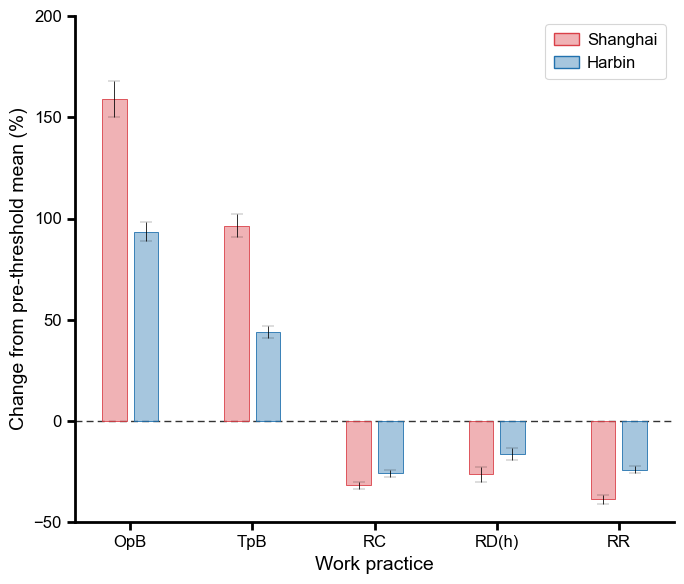


Figure saved to:
MainFigures\Fig2c.tiff


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import t as t_dist
import os

# ===============================
# Save directory
# ===============================
save_dir = str(OUTPUT_DIR)
os.makedirs(save_dir, exist_ok=True)

# ===============================
# Global journal‑style settings
# ===============================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 2,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# ===============================
# Color manager
# ===============================
def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)

COLORS = {
    "Shanghai": {
        "bar":  hex_to_rgba("#DA4048", 0.4),
        "ebar": "black",
        "edge": hex_to_rgba("#DA4048", 1)
    },
    "Harbin": {
        "bar":  hex_to_rgba("#2171AE", 0.4),
        "ebar": "black",
        "edge": hex_to_rgba("#2171AE", 1)
    }
}

# ===============================
# Use the English panel schema prepared above
# ===============================
df = df_merged.copy()

# ===============================
# Thresholds
# ===============================
thresholds = {"Shanghai": np.mean(tau_shanghai_bootstrap), "Harbin": np.mean(tau_harbin_bootstrap)}

# ===============================
# Derived variables
# ===============================
df["OrdersPerBatch"] = df["Orders"] / (df["RestCount"] + 1)
df["OnDutyPerBatch"] = df["On-dutyHour"] / (df["RestCount"] + 1)

# ===============================
# Variables to compare
# ===============================
vars_info = [
    ("OrdersPerBatch", "OpB"),
    ("OnDutyPerBatch", "TpB"),
    ("RestCount", "RC"),
    ("RestDuration", "RD(h)"),
    ("RestRatio", "RR"),
]

# ===============================
# Compute mean percentage change and 95% CI
# ===============================
plot_data = []
for var, short_name in vars_info:
    row = {"Variable": short_name}
    for city, th in thresholds.items():
        sub = df[df["Location"] == city].copy()
        sub = sub[~sub[var].isna()]

        before = sub.loc[(sub["Workload"] >= 20) & (sub["Workload"] <= th), var]
        mean_before = before.mean()

        after = sub.loc[sub["Workload"] > th, var]
        if pd.isna(mean_before) or mean_before == 0:
            mean_before = 1
        pct_change = (after / mean_before - 1) * 100
        pct_change = pct_change.replace([np.inf, -np.inf], np.nan).dropna()

        mean_val = pct_change.mean()
        n = pct_change.count()

        if n > 1:
            se = pct_change.std() / np.sqrt(n)
            t_crit = t_dist.ppf(0.975, df=n-1)
            ci_half = t_crit * se
        else:
            ci_half = np.nan

        row[f"{city}_mean"] = mean_val
        row[f"{city}_ci"] = ci_half
    plot_data.append(row)

plot_df = pd.DataFrame(plot_data)

# ===============================
# Plot
# ===============================
fig, ax = plt.subplots(figsize=(7, 6))
x = np.arange(len(vars_info))
bar_width = 0.2          # actual bar width
offset = 0.13            # distance from group center to bar center (controls gap)

# Bars
ax.bar(
    x - offset,
    plot_df["Shanghai_mean"],
    width=bar_width,
    color=COLORS["Shanghai"]["bar"],
    edgecolor=COLORS["Shanghai"]["edge"],
    linewidth=0.6,
    zorder=3,
    label="Shanghai",
)
ax.bar(
    x + offset,
    plot_df["Harbin_mean"],
    width=bar_width,
    color=COLORS["Harbin"]["bar"],
    edgecolor=COLORS["Harbin"]["edge"],
    linewidth=0.6,
    zorder=3,
    label="Harbin",
)

# Error bars (95% CI)
ax.errorbar(
    x - offset,
    plot_df["Shanghai_mean"],
    yerr=plot_df["Shanghai_ci"],
    fmt="none",
    ecolor=COLORS["Shanghai"]["ebar"],
    elinewidth=0.6,
    capsize=4,
    capthick=0.2,
    alpha=0.95,
    zorder=4,
)
ax.errorbar(
    x + offset,
    plot_df["Harbin_mean"],
    yerr=plot_df["Harbin_ci"],
    fmt="none",
    ecolor=COLORS["Harbin"]["ebar"],
    elinewidth=0.6,
    capsize=4,
    capthick=0.2,
    alpha=0.95,
    zorder=4,
)

# Reference line at zero
ax.axhline(0, color="black", linestyle=(0, (5, 3)), linewidth=1.0, alpha=0.8, zorder=2)

# Axes labels and limits
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Variable"])
ax.set_ylabel("Change from pre-threshold mean (%)")
ax.set_xlabel("Work practice")
ax.set_ylim(-50, 200)
ax.set_yticks(np.arange(-50, 201, 50))

# Legend
legend_elements = [
    Patch(facecolor=COLORS["Shanghai"]["bar"], edgecolor=COLORS["Shanghai"]["edge"], label="Shanghai"),
    Patch(facecolor=COLORS["Harbin"]["bar"], edgecolor=COLORS["Harbin"]["edge"], label="Harbin"),
]
leg = ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=True,
    borderpad=0.5,
    handlelength=1.5,
    handletextpad=0.5,
)
leg.get_frame().set_edgecolor("#CCCCCC")
leg.get_frame().set_linewidth(0.8)
leg.get_frame().set_facecolor("white")

# Save & show
plt.tight_layout()
output_path = os.path.join(save_dir, "Fig2c.tiff")
plt.savefig(output_path, dpi=600, format="tiff", bbox_inches="tight")
plt.show()
print(f"\nFigure saved to:\n{output_path}")

In [6]:
# Fig. 2c statistical summary calculation
import numpy as np
import pandas as pd
from scipy.stats import t as t_dist

thresholds = {"Shanghai": 50, "Harbin": 40}

fig2c_vars = [
    ("OrdersPerBatch", "Orders per batch"),
    ("OnDutyPerBatch", "On-duty hours per batch"),
    ("RestCount", "Rest count"),
    ("RestDuration", "Rest duration"),
    ("RestRatio", "Rest ratio"),
]

stats_df = df_merged.copy()
stats_df["OrdersPerBatch"] = stats_df["Orders"] / (stats_df["RestCount"] + 1)
stats_df["OnDutyPerBatch"] = stats_df["On-dutyHour"] / (stats_df["RestCount"] + 1)

def mean_ci(series, confidence=0.95):
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    n = values.size
    mean = values.mean()
    if n > 1:
        se = values.std(ddof=1) / np.sqrt(n)
        t_crit = t_dist.ppf((1 + confidence) / 2, df=n - 1)
        ci_half = t_crit * se
        ci_low = mean - ci_half
        ci_high = mean + ci_half
    else:
        ci_low = np.nan
        ci_high = np.nan
    return n, mean, ci_low, ci_high

summary_rows = []
for var, label in fig2c_vars:
    for city, threshold in thresholds.items():
        sub = stats_df.loc[stats_df["Location"] == city, ["Workload", var]].copy()
        sub = sub.dropna(subset=[var])

        pre = sub.loc[(sub["Workload"] >= 20) & (sub["Workload"] <= threshold), var]
        post = sub.loc[sub["Workload"] > threshold, var]

        pre_n, pre_mean, pre_ci_low, pre_ci_high = mean_ci(pre)
        post_n, post_mean, post_ci_low, post_ci_high = mean_ci(post)

        absolute_change = post - pre_mean
        change_n, change_mean, change_ci_low, change_ci_high = mean_ci(absolute_change)
        percent_change = change_mean / pre_mean * 100

        if var == "RestRatio":
            change_unit = "percentage points"
            display_change = change_mean * 100
            display_change_ci_low = change_ci_low * 100
            display_change_ci_high = change_ci_high * 100
        else:
            change_unit = "original units"
            display_change = change_mean
            display_change_ci_low = change_ci_low
            display_change_ci_high = change_ci_high

        summary_rows.append({
            "Variable": label,
            "City": city,
            "Pre-threshold n": pre_n,
            "Pre mean": pre_mean,
            "Pre 95% CI low": pre_ci_low,
            "Pre 95% CI high": pre_ci_high,
            "Post-threshold n": post_n,
            "Post mean": post_mean,
            "Post 95% CI low": post_ci_low,
            "Post 95% CI high": post_ci_high,
            "Absolute change": display_change,
            "Change 95% CI low": display_change_ci_low,
            "Change 95% CI high": display_change_ci_high,
            "Change unit": change_unit,
            "Percent change (%)": percent_change,
        })

fig2c_stats = pd.DataFrame(summary_rows)

display(
    fig2c_stats.style.format({
        "Pre mean": "{:.4f}",
        "Pre 95% CI low": "{:.4f}",
        "Pre 95% CI high": "{:.4f}",
        "Post mean": "{:.4f}",
        "Post 95% CI low": "{:.4f}",
        "Post 95% CI high": "{:.4f}",
        "Absolute change": "{:.4f}",
        "Change 95% CI low": "{:.4f}",
        "Change 95% CI high": "{:.4f}",
        "Percent change (%)": "{:.4f}",
    })
)

def format_fig2c_markdown_row(row):
    if row["Change unit"] == "percentage points":
        change_text = (
            f'{row["Absolute change"]:.2f} pp '
            f'[{row["Change 95% CI low"]:.2f}, {row["Change 95% CI high"]:.2f}]'
        )
    else:
        unit = "orders" if row["Variable"] == "Orders per batch" else "hours" if "hours" in row["Variable"] or row["Variable"] == "Rest duration" else "breaks"
        change_text = (
            f'{row["Absolute change"]:.4f} {unit} '
            f'[{row["Change 95% CI low"]:.4f}, {row["Change 95% CI high"]:.4f}]'
        )

    return (
        f'| {row["Variable"]} | {row["City"]} | {int(row["Pre-threshold n"]):,} | '
        f'{row["Pre mean"]:.4f} [{row["Pre 95% CI low"]:.4f}, {row["Pre 95% CI high"]:.4f}] | '
        f'{int(row["Post-threshold n"]):,} | '
        f'{row["Post mean"]:.4f} [{row["Post 95% CI low"]:.4f}, {row["Post 95% CI high"]:.4f}] | '
        f'{change_text} | {row["Percent change (%)"]:+.4f}% |'
    )

fig2c_stats_markdown = "\n".join(fig2c_stats.apply(format_fig2c_markdown_row, axis=1))
print(fig2c_stats_markdown)


,Variable,City,Pre-threshold n,Pre mean,Pre 95% CI low,Pre 95% CI high,Post-threshold n,Post mean,Post 95% CI low,Post 95% CI high,Absolute change,Change 95% CI low,Change 95% CI high,Change unit,Percent change (%)
0,Orders per batch,Shanghai,19086,11.7940,11.6968,11.8912,2653,28.0139,27.2166,28.8112,16.2199,15.4226,17.0172,original units,137.5265
1,Orders per batch,Harbin,8891,12.7783,12.6236,12.9330,2691,24.5601,24.0167,25.1034,11.7818,11.2384,12.3251,original units,92.2013
2,On-duty hours per batch,Shanghai,19086,1.7325,1.7187,1.7463,2653,3.2123,3.1336,3.2910,1.4798,1.4011,1.5585,original units,85.4124
3,On-duty hours per batch,Harbin,8891,2.4353,2.4067,2.4640,2691,3.5071,3.4413,3.5730,1.0718,1.0059,1.1377,original units,44.0106
4,Rest count,Shanghai,19086,4.0402,4.0097,4.0708,2653,2.9412,2.8760,3.0064,-1.0990,-1.1643,-1.0338,original units,-27.2024
5,Rest count,Harbin,8891,3.2300,3.1908,3.2692,2691,2.4106,2.3573,2.4639,-0.8194,-0.8727,-0.7661,original units,-25.3677
6,Rest duration,Shanghai,19086,4.1296,4.0837,4.1754,2653,3.1865,3.0566,3.3164,-0.9431,-1.0730,-0.8132,original units,-22.8372
7,Rest duration,Harbin,8891,3.7623,3.7020,3.8225,2691,3.1965,3.0889,3.3041,-0.5658,-0.6734,-0.4582,original units,-15.0387
8,Rest ratio,Shanghai,19086,0.3352,0.3331,0.3373,2653,0.2131,0.2074,0.2187,-12.2127,-12.7775,-11.6478,percentage points,-36.4321
9,Rest ratio,Harbin,8891,0.2891,0.2863,0.2918,2691,0.2222,0.2175,0.2268,-6.6897,-7.1523,-6.2271,percentage points,-23.1425


| Orders per batch | Shanghai | 19,086 | 11.7940 [11.6968, 11.8912] | 2,653 | 28.0139 [27.2166, 28.8112] | 16.2199 orders [15.4226, 17.0172] | +137.5265% |
| Orders per batch | Harbin | 8,891 | 12.7783 [12.6236, 12.9330] | 2,691 | 24.5601 [24.0167, 25.1034] | 11.7818 orders [11.2384, 12.3251] | +92.2013% |
| On-duty hours per batch | Shanghai | 19,086 | 1.7325 [1.7187, 1.7463] | 2,653 | 3.2123 [3.1336, 3.2910] | 1.4798 hours [1.4011, 1.5585] | +85.4124% |
| On-duty hours per batch | Harbin | 8,891 | 2.4353 [2.4067, 2.4640] | 2,691 | 3.5071 [3.4413, 3.5730] | 1.0718 hours [1.0059, 1.1377] | +44.0106% |
| Rest count | Shanghai | 19,086 | 4.0402 [4.0097, 4.0708] | 2,653 | 2.9412 [2.8760, 3.0064] | -1.0990 breaks [-1.1643, -1.0338] | -27.2024% |
| Rest count | Harbin | 8,891 | 3.2300 [3.1908, 3.2692] | 2,691 | 2.4106 [2.3573, 2.4639] | -0.8194 breaks [-0.8727, -0.7661] | -25.3677% |
| Rest duration | Shanghai | 19,086 | 4.1296 [4.0837, 4.1754] | 2,653 | 3.1865 [3.0566, 3.3164] | -0.9431 ho